# Extended Data Fig. 18 — Permutation validation of NeuN+ decrease in low-cell-count regions

This notebook tests whether the App<sup>NL-G-F</sup>-specific NeuN+ decreases detected in anatomically small / low-count compartments — **fiber tracts** (Extended Data Fig. 18b) and **cortical layer 6b** (Extended Data Fig. 18d) — could be explained by chance fluctuation arising from small cell numbers.

For each region we fit the slope of NeuN+ cell count versus age (1–9 months) and assess its significance with a **10,000-iteration label-permutation test** (one-sided, testing for a decreasing trend). Regions that remain significant after permutation are not readily explained by low-count chance effects.

The notebook has two parts (fiber tracts, then layer 6b); each part (i) selects the target regions, (ii) runs the permutation test, and (iii) plots significance versus baseline cell count.

## Input files

All inputs are region-level intermediate results produced by the upstream whole-brain pipeline (see repository README, *Main Steps* 1–2 and *Advanced Analyses*). Paths below point to the lab data server; the corresponding region-level tables are also provided on the project Google Drive.

| Variable | File | Content |
|---|---|---|
| `region_color_path` | `GOvsID_6region_removed.csv` | Allen CCFv3 region `id` + display color (`R,G,B`) |
| `region_summary_path` | `summary_CUBIC-Atlas-1-1.csv` | region `id` ↔ `acronym` lookup |
| `allen_graph_path` | `Allen_graph.json` | Allen structure tree (used to find descendants of *fiber tracts*, id 1009) |
| `region_dir` | `.../Region/` | App / WT region-level CSVs (see below) |

Inside `region_dir`:
- `APP_raw_value_regions_NeuN_decrease.csv` — atlas IDs showing App-specific NeuN+ decrease
- `APP_WT_interaction_term_APP_raw_value_regions_NeuN_all.csv` — App mean NeuN+ value per region per age (for onset detection)

Per-brain cell counts are read for each sample via `param/Neuronomics/<sample>/param_multichannel-rank.json` → `dst_basedir` → `<dst_basedir>/Regional_cellome4.csv`.

In [ ]:
import os, json, re
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import ruptures as rpt
from scipy.stats import linregress
from adjustText import adjust_text

matplotlib.rcParams['pdf.use14corefonts'] = True
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.size'] = 20

In [ ]:
# ---- Input paths (lab data server; region-level tables also on the project Google Drive) ----
region_color_path   = "/export3/Imaging/atlas_for_fig/GOvsID_6region_removed.csv"
region_summary_path = "/export3/Imaging/cubic-atlas_v1-1/cubic-atlas/summary_CUBIC-Atlas-1-1.csv"
allen_graph_path    = "/export3/Imaging/Axial/Neurorology/8w_B6JWT_atlas_1_2022_0924_1847/Allen_graph.json"
region_dir          = "/export3/Imaging/ds4_Data4/Neurology_project_data_archive/Region/"

# Region color table (Allen region id + RGB), used for scatter-plot colors
data_GO = pd.read_csv(region_color_path, encoding="ms932", sep=",")
# Region id <-> acronym lookup
data_id = pd.read_csv(region_summary_path, encoding="ms932", sep=",")
# Region id -> acronym (used for plot labels)
id_to_acronym = data_id.set_index('id')['acronym']

In [ ]:
# Sample IDs (cleared-brain datasets) grouped by model and age.
# Only the WT and App groups are used here.
conditions = {
    "WT_0.2m": ["#3_1w_B6JWT_atlas_1_2022_1103_2305","1w_B6JWT_atlas_2_2022_1219_1829", "1w_B6JWT_atlas_3_2022_1223_1719", "1w_B6JWT_atlas_4_2023_0105_1708"],
    "WT_0.75m": ["3w_B6JWT_atlas_1_2022_0925_1526", "3w_B6JWT_atlas_2_2022_1004_928", "3w_B6JWT_atlas_3_2022_1017_2126", "3w_B6JWT_atlas_4_2022_1130_1051"],
    
    "WT_1m": ["#4_APPmodel_Ctr1m_1_2022_1104_1550","#4_APPmodel_Ctr1m_2_2022_1108_959","#4_APPmodel_Ctr1m_3_2022_1209_1751"],
    "WT_2m": ["8w_B6JWT_atlas_1_2022_0924_1847","8w_B6JWT_atlas_2_2022_0926_1326", "8w_B6JWT_atlas_3_2022_1005_1110", "8w_B6JWT_atlas_4_2022_1010_2030","8w_B6JWT_atlas_5_2023_0423_1604",],
    "WT_3m": ["#5_APPmodel_Ctr3m_1_2023_0113_1230", "#5_APPmodel_Ctr3m_2_2023_0210_1142", "#5_APPmodel_Ctr3m_3_2023_0227_1605", "#4_APPmodel_Ctr3m_4_2023_0427_1444",],
    "WT_5m": ["#4_APPmodel_Ctr5m_1_2022_1026_252", "#4_APPmodel_Ctr5m_2_2022_1028_2336", "#4_APPmodel_Ctr5m_3_2022_1101_140", "#4_APPmodel_Ctr5m_4_2023_0512_2057"],
    "WT_7m": [ "#5_APPmodel_Ctr7m_1_2023_0206_1534","#5_APPmodel_Ctr7m_2_2023_0313_1111","#5_APPmodel_Ctr7m_3_2023_0331_2139","#4_APPmodel_Ctr7m_4_2023_0516_1559","#5_APPmodel_Ctr7m_5_2023_0522_2218"],
    "WT_9m": [ "#5_APPmodel_Ctr9m_1_2023_0130_1607", "#5_APPmodel_Ctr9m_2_2023_0216_2052" ,"#5_APPmodel_Ctr9m_3_2023_0322_2014","#5_APPmodel_Ctr9m_4_2023_0518_1449"],
    "WT_12m": ["56w_B6JWT_atlas_1_2022_1128_1548", "56w_B6JWT_atlas_2_2022_1221_1537", "56w_B6JWT_atlas_3_2022_1224_1718"],
    "APP_1m": ["#4_APPmodel_APP1m_1_2022_1102_1304", "#4_APPmodel_APP1m_2_2022_1106_1708","#4_APPmodel_APP1m_3_2022_1213_2151","#4_APPmodel_APP1m_4_2023_0417_2052", ],
    "APP_3m": [ "#5_APPmodel_APP3m_2_2023_0123_1645", "#5_APPmodel_APP3m_3_2023_0212_2217","#5_APPmodel_APP3m_4_2023_0214_2027","#4_APPmodel_APP3m_5_2023_0502_1423",],
    "APP_5m": ["#4_APPmodel_APP5m_1_2022_1024_1336", "#4_APPmodel_APP5m_2_2022_1027_1333","#4_APPmodel_APP5m_3_2022_1030_1257", "#4_APPmodel_APP5m_4_2023_0509_1021"],
    "APP_7m": ["#5_APPmodel_APP7m_2_2023_0315_1540","#5_APPmodel_APP7m_3_2023_0310_1401","#5_APPmodel_APP7m_4_2023_0317_1630", "#5_APPmodel_APP7m_5_2023_0520_1723"],
    "APP_9m": ["#5_APPmodel_APP9m_1_2023_0117_1352","#5_APPmodel_APP9m_2_2023_0327_1425", "#5_APPmodel_APP9m_3_2023_0329_1611", "#5_APPmodel_APP9m_4_2023_0403_1443" ],
    
    "VCP_mut_2m": ["VCPmodel_E524A_0.5x_1_2022_0624_1303", "VCPmodel_E524A_0.5x_2_2022_0626_1338", "VCPmodel_E524A_0.5x_4_2022_0922_1217", "VCPmodel_E524A_0.5x_6_2022_0628_1157"], 
    "VCP_WT_2m": ["VCPmodel_WT_0.5x_1_2022_0625_1104","VCPmodel_WT_0.5x_2_2022_0917_1808", "VCPmodel_WT_0.5x_3_2022_0627_1257", "VCPmodel_WT_0.5x_4_2022_0921_950","VCPmodel_WT_0.5x_5_2022_0923_1454","VCPmodel_WT_0.5x_6_2022_0929_953"],
    "new_VCP_mut_2m": ["#5_VCPmodel_E524A_0.5x_1_2023_0120_1929","#5_VCPmodel_E524A_0.5x_2_2023_0407_1031", "#5_VCPmodel_E524A_0.5x_3_2023_0413_2036"], 
    "new_VCP_WT_2m": ["#5_VCPmodel_WT_0.5x_1_2023_0405_1108","#5_VCPmodel_WT_0.5x_2_2023_0115_1852","#5_VCPmodel_WT_0.5x_3_2023_0410_1246"], 
    
    "TMT_2m": ["#3_TMTmodel_TMT3.0_8w_1_2022_1014_1410", "#3_TMTmodel_TMT3.0_8w_2_2022_1020_938", "#3_TMTmodel_TMT3.0_8w_3_2022_1023_501", "#3_TMTmodel_TMT_8w_5_2022_1205_1147",],
    "Saline_2m": ["#3_TMTmodel_Saline_8w_1_2022_1016_1318", "#3_TMTmodel_Saline_8w_2_2022_1018_2103","#3_TMTmodel_Saline_8w_3_2022_1021_1910", "#3_TMTmodel_Saline_8w_4_2022_1202_1349", "#3_TMTmodel_Saline_8w_5_2022_1217_1723", "#3_TMTmodel_Saline_8w_6_2022_1216_001"],
    
}

In [ ]:
# ---- Shared helper functions ----

def load_data(sample_info):
    """Load per-region cell counts (Regional_cellome4.csv) for each (sample, condition)."""
    df_list = []
    for sample, condition in sample_info:
        param_path = f"/home/mitani/CUBIC-informatics/param/Neuronomics/{sample}/param_multichannel-rank.json"
        try:
            with open(param_path) as f:
                param = json.load(f)
            fw_dir_nu = param['dst_basedir']
            # normalize archived paths
            if ('Neurology_project_data_archive' not in fw_dir_nu
                    and re.search(r'/ds4_Data\d+/', fw_dir_nu)):
                fw_dir_nu = re.sub(r'(/ds4_Data\d+/)', r'\1Neurology_project_data_archive/', fw_dir_nu)
            cellome_file = fw_dir_nu + '/Regional_cellome4.csv'
            if os.path.exists(cellome_file):
                df = pd.read_csv(cellome_file)
                df['Condition'] = condition
                df['Sample'] = sample
                df_list.append(df)
        except Exception as e:
            print(f'Error loading data for {sample}: {e}')
    return pd.concat(df_list, ignore_index=True) if df_list else pd.DataFrame()


def detect_change_points(data):
    """Single change-point (onset age) per region via ruptures (L2 / Binseg)."""
    cp_dict = {}
    months = np.array([1, 3, 5, 7, 9])
    for atlas_id, row in data.iterrows():
        values = row.values.astype(float)
        algo = rpt.Binseg(model='l2', min_size=1, jump=1).fit(values)
        result = algo.predict(n_bkps=1)
        cp = months[0] if (not result or len(result) < 2) else months[np.array(result[:-1])[0]]
        cp_dict[atlas_id] = cp
    return cp_dict


def run_permutation_test_regression(months, counts, n_permutations=10000):
    """Permutation test for the regression slope of NeuN+ count (y) vs. age (x).
    One-sided test for a decreasing trend (negative slope).
    Returns (observed_slope, permutation_p_value)."""
    x_labels = np.array(months)
    y_values = np.array(counts)
    if len(x_labels) < 3:                      # need at least 3 points
        return np.nan, 1.0
    try:
        obs_slope, _, _, _, _ = linregress(x_labels, y_values)
    except ValueError as e:
        print(f'  linregress error: {e}')
        return np.nan, 1.0
    extreme_count = 0
    for _ in range(n_permutations):
        shuffled_x = np.random.permutation(x_labels)        # shuffle age labels
        perm_slope, _, _, _, _ = linregress(shuffled_x, y_values)
        if perm_slope <= obs_slope:                          # as/more extreme (decreasing)
            extreme_count += 1
    return obs_slope, (extreme_count + 1) / (n_permutations + 1)   # +1 correction

## Part 1 — Fiber tracts (Extended Data Fig. 18b)

Target regions = regions that are **both** App-specific NeuN-decrease regions **and** descendants of the Allen *fiber tracts* structure (id 1009).

In [ ]:
# --- Select regions: App-specific NeuN decrease AND fiber tracts; compute onset ---
months_np = np.array([1, 3, 5, 7, 9])
col_names_app = [f'APP_{m}m' for m in months_np]
all_months = ['1m', '3m', '5m', '7m', '9m']

# App per-brain raw region data
app_conditions = [f'APP_{m}' for m in all_months]
disease_sample_info = [(s, c) for c in app_conditions if c in conditions for s in conditions[c]]
all_raw_data = load_data(disease_sample_info).copy()
all_raw_data['Month'] = all_raw_data['Condition'].str.extract(r'(\d+)m').astype(int)
all_raw_data['Group'] = all_raw_data['Condition'].str.split('_').str[0]   # 'APP'

# App-specific NeuN-decrease region ids
app_decrease_df = pd.read_csv(os.path.join(region_dir, 'APP_raw_value_regions_NeuN_decrease.csv'), index_col='atlasID')
app_decrease_ids = set(app_decrease_df.index)

# Fiber-tract region ids = descendants of Allen structure id 1009
with open(allen_graph_path) as f:
    allen_graph = json.load(f)
FIBER_TRACT_ID = 1009
fiber_tract_ids = {el['id'] for el in allen_graph if FIBER_TRACT_ID in el['structure_id_path']}

# App mean values per region per age (for onset detection)
app_all_values_df = pd.read_csv(os.path.join(region_dir, 'APP_WT_interaction_term_APP_raw_value_regions_NeuN_all.csv'), index_col='atlasID')

# Overlap = App-decrease AND fiber tract
overlap_ids = (app_decrease_ids & fiber_tract_ids) & set(app_all_values_df.index)
app_overlap_values = app_all_values_df.loc[overlap_ids, col_names_app]
change_points = detect_change_points(app_overlap_values)
sorted_regions = sorted(change_points, key=lambda r: change_points[r])
print(f'Fiber-tract regions with App-specific NeuN decrease: {len(sorted_regions)}')

In [ ]:
# --- Permutation test (App time-series slope) over fiber-tract regions ---
N_PERMUTATIONS = 10000
permutation_results = []
for region_id in sorted_regions:
    acronym = id_to_acronym.get(region_id, str(region_id))
    region_data_app = all_raw_data[(all_raw_data['atlasID'] == region_id) & (all_raw_data['Group'] == 'APP')]
    months_list = region_data_app['Month']
    counts_list = region_data_app['NeuN_cell_count']
    if len(months_list) < 3:
        print(f'  Warning: <3 App time points for {acronym}; skipping.')
        continue
    avg_counts = region_data_app.groupby('Month')['NeuN_cell_count'].mean()
    obs_slope, p_value = run_permutation_test_regression(months_list, counts_list, N_PERMUTATIONS)
    print(f'{acronym} (ID {region_id}): slope={obs_slope:.2f}, permutation p={p_value:.4f}')
    permutation_results.append({'AtlasID': region_id, 'Acronym': acronym,
        'Observed_Slope': obs_slope, 'Permutation_P_Value': p_value, 'N_Samples': len(counts_list),
        'Avg_Count_1m': avg_counts.get(1, np.nan), 'Avg_Count_9m': avg_counts.get(9, np.nan)})

results_df = pd.DataFrame(permutation_results).sort_values(by='Permutation_P_Value')
pd.set_option('display.max_rows', None); pd.set_option('display.max_columns', None); pd.set_option('display.width', 1000)
results_df.to_csv('ED18_fibertract_permutation_results.csv', index=False)
results_df

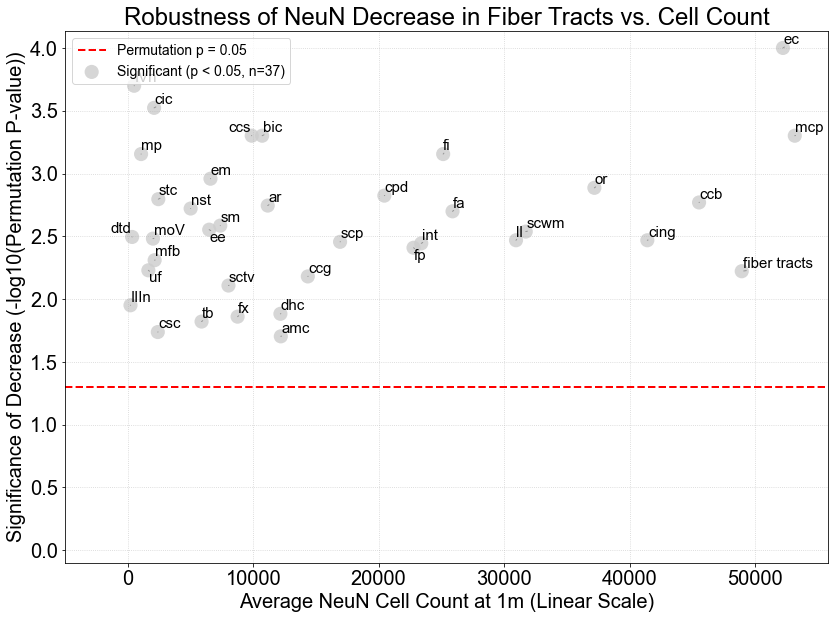

In [ ]:
# --- Scatter: significance (-log10 permutation p) vs. baseline cell count (Extended Data Fig. 18b) ---
color_map_df = data_GO[['id', 'R', 'G', 'B']].copy()
color_map_df['color'] = color_map_df.apply(lambda r: (r['R']/255, r['G']/255, r['B']/255), axis=1)
plot_df = pd.merge(results_df, color_map_df[['id', 'color']], left_on='AtlasID', right_on='id', how='left')
plot_df['color'] = plot_df['color'].apply(lambda c: c if isinstance(c, tuple) else (0.5, 0.5, 0.5))
plot_df['-log10(P-value)'] = -np.log10(plot_df['Permutation_P_Value'])
sig_threshold = -np.log10(0.05)

texts = []
plt.figure(figsize=(12, 9)); ax = plt.gca()
sig_df = plot_df[plot_df['Permutation_P_Value'] < 0.05]
ax.scatter(sig_df['Avg_Count_1m'], sig_df['-log10(P-value)'], s=200, color=sig_df['color'].tolist(),
           alpha=0.8, label=f'Significant (p < 0.05, n={len(sig_df)})', edgecolors='none')
nonsig_df = plot_df[plot_df['Permutation_P_Value'] >= 0.05]
if not nonsig_df.empty:
    ax.scatter(nonsig_df['Avg_Count_1m'], nonsig_df['-log10(P-value)'], s=200, color=nonsig_df['color'].tolist(),
               alpha=0.3, label=f'Not significant (p >= 0.05, n={len(nonsig_df)})', edgecolors='none')
for _, row in sig_df.iterrows():
    texts.append(ax.text(row['Avg_Count_1m'], row['-log10(P-value)'], row['Acronym'], fontsize=15))
adjust_text(texts, arrowprops=dict(arrowstyle='-', color='black', alpha=0.3))
ax.axhline(y=sig_threshold, color='red', linestyle='--', linewidth=2, label='Permutation p = 0.05')
ax.set_xlabel('Average NeuN cell count at 1m (linear scale)')
ax.set_ylabel('Significance of decrease (-log10 permutation p)')
ax.set_title('Robustness of NeuN decrease in fiber tracts vs. cell count')
ax.legend(fontsize=14); ax.grid(True, linestyle=':', alpha=0.6)
ax.set_xlim(left=-5000); ax.set_ylim(bottom=-0.1)
plt.tight_layout()
plt.savefig('ED18b_fibertract_permutation_scatter.pdf', dpi=300)
plt.show(); plt.close()

## Part 2 — Cortical layer 6b (Extended Data Fig. 18d)

Target regions = regions that are **both** App-specific NeuN-decrease regions **and** whose acronym contains "6b".

In [ ]:
# --- Select regions: App-specific NeuN decrease AND layer 6b; compute onset ---
# App per-brain raw region data (reuse loader)
app_conditions = [f'APP_{m}' for m in all_months]
disease_sample_info = [(s, c) for c in app_conditions if c in conditions for s in conditions[c]]
all_raw_data = load_data(disease_sample_info).copy()
all_raw_data['Month'] = all_raw_data['Condition'].str.extract(r'(\d+)m').astype(int)
all_raw_data['Group'] = all_raw_data['Condition'].str.split('_').str[0]

app_decrease_df = pd.read_csv(os.path.join(region_dir, 'APP_raw_value_regions_NeuN_decrease.csv'), index_col='atlasID')
app_decrease_ids = set(app_decrease_df.index)

# Layer 6b region ids = acronym contains '6b'
layer_6b_ids = set(data_id[data_id['acronym'].str.contains('6b', na=False)]['id'])

app_all_values_df = pd.read_csv(os.path.join(region_dir, 'APP_WT_interaction_term_APP_raw_value_regions_NeuN_all.csv'), index_col='atlasID')
overlap_ids = (app_decrease_ids & layer_6b_ids) & set(app_all_values_df.index)
app_overlap_values = app_all_values_df.loc[overlap_ids, col_names_app]
change_points = detect_change_points(app_overlap_values)
sorted_regions = sorted(change_points, key=lambda r: change_points[r])
print(f'Layer-6b regions with App-specific NeuN decrease: {len(sorted_regions)}')

In [ ]:
# --- Permutation test (App time-series slope) over layer-6b regions ---
N_PERMUTATIONS = 10000
permutation_results = []
for region_id in sorted_regions:
    acronym = id_to_acronym.get(region_id, str(region_id))
    region_data_app = all_raw_data[(all_raw_data['atlasID'] == region_id) & (all_raw_data['Group'] == 'APP')]
    months_list = region_data_app['Month']
    counts_list = region_data_app['NeuN_cell_count']
    if len(months_list) < 3:
        print(f'  Warning: <3 App time points for {acronym}; skipping.')
        continue
    avg_counts = region_data_app.groupby('Month')['NeuN_cell_count'].mean()
    obs_slope, p_value = run_permutation_test_regression(months_list, counts_list, N_PERMUTATIONS)
    print(f'{acronym} (ID {region_id}): slope={obs_slope:.2f}, permutation p={p_value:.4f}')
    permutation_results.append({'AtlasID': region_id, 'Acronym': acronym,
        'Observed_Slope': obs_slope, 'Permutation_P_Value': p_value, 'N_Samples': len(counts_list),
        'Avg_Count_1m': avg_counts.get(1, np.nan), 'Avg_Count_9m': avg_counts.get(9, np.nan)})

results_df_6b = pd.DataFrame(permutation_results).sort_values(by='Permutation_P_Value')
results_df_6b.to_csv('ED18_layer6b_permutation_results.csv', index=False)
results_df_6b

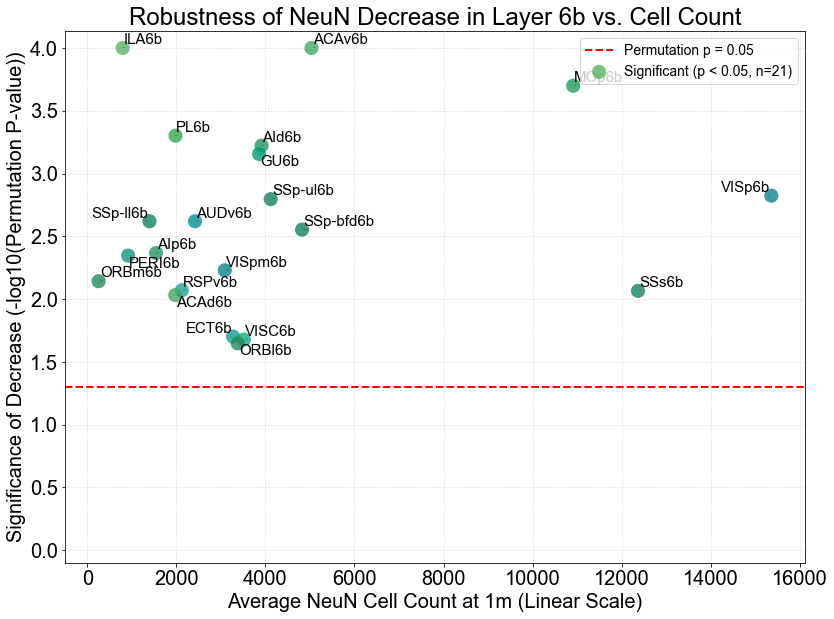

In [ ]:
# --- Scatter: significance (-log10 permutation p) vs. baseline cell count (Extended Data Fig. 18d) ---
color_map_df = data_GO[['id', 'R', 'G', 'B']].copy()
color_map_df['color'] = color_map_df.apply(lambda r: (r['R']/255, r['G']/255, r['B']/255), axis=1)
plot_df = pd.merge(results_df_6b, color_map_df[['id', 'color']], left_on='AtlasID', right_on='id', how='left')
plot_df['color'] = plot_df['color'].apply(lambda c: c if isinstance(c, tuple) else (0.5, 0.5, 0.5))
plot_df['-log10(P-value)'] = -np.log10(plot_df['Permutation_P_Value'])
sig_threshold = -np.log10(0.05)

texts = []
plt.figure(figsize=(12, 9)); ax = plt.gca()
sig_df = plot_df[plot_df['Permutation_P_Value'] < 0.05]
ax.scatter(sig_df['Avg_Count_1m'], sig_df['-log10(P-value)'], s=200, color=sig_df['color'].tolist(),
           alpha=0.8, label=f'Significant (p < 0.05, n={len(sig_df)})', edgecolors='none')
nonsig_df = plot_df[plot_df['Permutation_P_Value'] >= 0.05]
if not nonsig_df.empty:
    ax.scatter(nonsig_df['Avg_Count_1m'], nonsig_df['-log10(P-value)'], s=200, color=nonsig_df['color'].tolist(),
               alpha=0.3, label=f'Not significant (p >= 0.05, n={len(nonsig_df)})', edgecolors='none')
for _, row in sig_df.iterrows():
    texts.append(ax.text(row['Avg_Count_1m'], row['-log10(P-value)'], row['Acronym'], fontsize=15))
adjust_text(texts, arrowprops=dict(arrowstyle='-', color='black', alpha=0.3))
ax.axhline(y=sig_threshold, color='red', linestyle='--', linewidth=2, label='Permutation p = 0.05')
ax.set_xlabel('Average NeuN cell count at 1m (linear scale)')
ax.set_ylabel('Significance of decrease (-log10 permutation p)')
ax.set_title('Robustness of NeuN decrease in layer 6b vs. cell count')
ax.legend(fontsize=14); ax.grid(True, linestyle=':', alpha=0.6)
ax.set_xlim(left=-500); ax.set_ylim(bottom=-0.1)
plt.tight_layout()
plt.savefig('ED18d_layer6b_permutation_scatter.pdf', dpi=300)
plt.show(); plt.close()